## Automobile Data Advanced Analysis 

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv('Automobile_data.csv')

In [76]:
df.head()

,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
0,0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0
1,1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
2,2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0
3,3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0
4,4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             61 non-null     int64  
 1   company           61 non-null     object 
 2   body-style        61 non-null     object 
 3   wheel-base        61 non-null     float64
 4   length            61 non-null     float64
 5   engine-type       61 non-null     object 
 6   num-of-cylinders  61 non-null     object 
 7   horsepower        61 non-null     int64  
 8   average-mileage   61 non-null     int64  
 9   price             58 non-null     float64
dtypes: float64(3), int64(3), object(4)
memory usage: 4.9+ KB


### 1. Identify Duplicate Records with Different Prices 
Find all cars that have the same company, body-style, engine-type, and horsepower, but different prices. Print the duplicate entries.

In [78]:
df.head()

,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
0,0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0
1,1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
2,2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0
3,3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0
4,4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0


In [79]:
df.drop(columns='index', inplace=True)

In [80]:
df.head()

,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0
1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0
3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0
4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0


In [81]:
df.columns

Index(['company', 'body-style', 'wheel-base', 'length', 'engine-type',
       'num-of-cylinders', 'horsepower', 'average-mileage', 'price'],
      dtype='object')

In [82]:
df[df[['company', 'body-style', 'wheel-base', 'length', 'engine-type',
       'num-of-cylinders', 'horsepower', 'average-mileage']].duplicated()]

,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
8,bmw,sedan,101.2,176.8,ohc,four,101,23,16925.0
17,dodge,hatchback,93.7,157.3,ohc,four,68,31,6229.0
23,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN
25,jaguar,sedan,113.0,199.6,dohc,six,176,15,35550.0
29,mazda,hatchback,93.1,159.1,ohc,four,68,31,6795.0
39,mitsubishi,sedan,96.3,172.4,ohc,four,88,25,8189.0
42,nissan,sedan,94.5,165.3,ohc,four,69,31,6849.0
50,toyota,hatchback,95.7,158.7,ohc,four,62,31,6488.0
53,toyota,wagon,95.7,169.7,ohc,four,62,27,8778.0


### 2. Find the Most Powerful Car per Company
For each car company, find the car(s) with the maximum horsepower and display their full details.

In [83]:
df[df['horsepower'] == df.groupby("company")["horsepower"].transform('max')]

,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0
4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0
10,bmw,sedan,103.5,189.0,ohc,six,182,16,30760.0
11,bmw,sedan,103.5,193.8,ohc,six,182,16,41315.0
12,bmw,sedan,110.0,197.0,ohc,six,182,15,36880.0
14,chevrolet,hatchback,94.5,155.9,ohc,four,70,38,6295.0
15,chevrolet,sedan,94.5,158.8,ohc,four,70,38,6575.0
16,dodge,hatchback,93.7,157.3,ohc,four,68,31,6377.0
17,dodge,hatchback,93.7,157.3,ohc,four,68,31,6229.0
19,honda,sedan,96.5,175.4,ohc,four,101,24,12945.0


### 3. Price-to-Performance Ratio
Create a new column called price_per_hp that is the ratio of price to horsepower. Then, find the top 3 cars with the lowest price_per_hp (i.e., best performance for the price).

In [84]:
df['price_per_hp'] = df['price'] / df['horsepower']

In [85]:
df.head()

,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price,price_per_hp
0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0,121.576577
1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0,148.648649
2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0,107.142857
3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0,136.764706
4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0,151.739130


In [86]:
df.sort_values(by ='price_per_hp').head(3)

,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price,price_per_hp
27,mazda,hatchback,93.1,159.1,ohc,four,68,30,5195.0,76.397059
36,mitsubishi,hatchback,93.7,157.3,ohc,four,68,37,5389.0,79.250000
38,mitsubishi,sedan,96.3,172.4,ohc,four,88,25,6989.0,79.420455


### 4. Classify Cars Based on Performance
Classify each car as "High Performance", "Medium Performance", or "Low Performance" based on the following rules:

High: horsepower > 130

Medium: 100 ≤ horsepower ≤ 130

Low: horsepower < 100

Add a new column for this classification and count how many cars fall into each category.

In [87]:
df['performance'] = df['horsepower'].apply(
     lambda x : "High" if x > 130 else "medium" if x >=100 else "Low")

In [88]:
df.head()

,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price,price_per_hp,performance
0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0,121.576577,medium
1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0,148.648649,medium
2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0,107.142857,High
3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0,136.764706,medium
4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0,151.739130,medium


In [89]:
df['performance'].value_counts()

performance
Low       30
medium    17
High      14
Name: count, dtype: int64

### 5. Compare Body Styles by Average Metrics
Group the cars by body-style and compare the average values for horsepower, mileage, and price. Rank body styles from best to worst in terms of horsepower and mileage combined.

In [90]:
df.groupby("body-style")[['horsepower', 'average-mileage', 'price']].mean().round(1).reset_index().sort_values(by=['horsepower', 'average-mileage'],ascending=False)

,body-style,horsepower,average-mileage,price
1,hardtop,195.5,15.5,39714.0
0,convertible,143.0,19.7,22341.0
3,sedan,112.6,24.9,17706.3
4,wagon,92.7,25.4,12730.1
2,hatchback,88.2,30.5,7159.6


### 6. Remove Outliers in Price Column
Remove the rows where the price is an outlier (using IQR method) and return the cleaned DataFrame. Show how many rows were removed.

<Axes: >

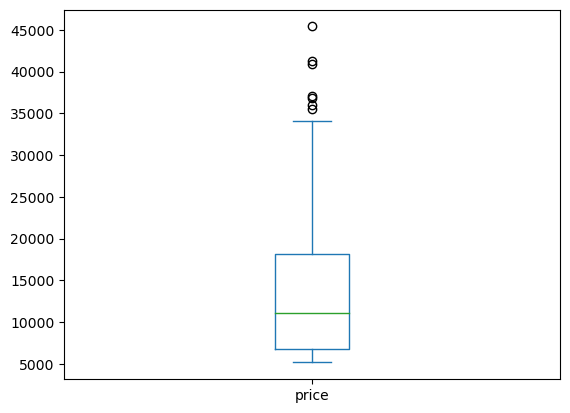

In [91]:
df['price'].plot(kind='box')

In [92]:
old = df.shape[0]

In [93]:
q1 = df['price'].quantile(0.25)
q1

6808.5

In [94]:
q3 = df['price'].quantile(0.75)
q3

18120.5

In [95]:
iqr = q3 - q1
iqr

11312.0

In [96]:
lb = q1 - iqr*1.5
ub = q3 + iqr*1.5

In [97]:
clean_data = df[df['price'].between(lb, ub)]

In [98]:
old - clean_data.shape[0]

10

### 7. Detect Inconsistencies in Engine-Type and Horsepower
Check if any engine-type is associated with drastically inconsistent horsepower values (e.g., >40% variance). List those engine-types and their max-min horsepower range.

In [99]:
engine = df.groupby("engine-type")['horsepower'].agg(['min', 'max']).reset_index()

In [100]:
engine[(((engine['max'] - engine['min']) / engine['max'])*100 ) > 40]


,engine-type,min,max
3,ohc,52,182
5,ohcv,152,262


### 8. Analyze Mileage vs Price Relationship
Create a correlation coefficient and a scatter plot between average-mileage and price. Determine if mileage significantly affects price.

In [101]:
df['average-mileage'].corr(df['price'])

-0.7702172796214722

<Axes: xlabel='average-mileage', ylabel='price'>

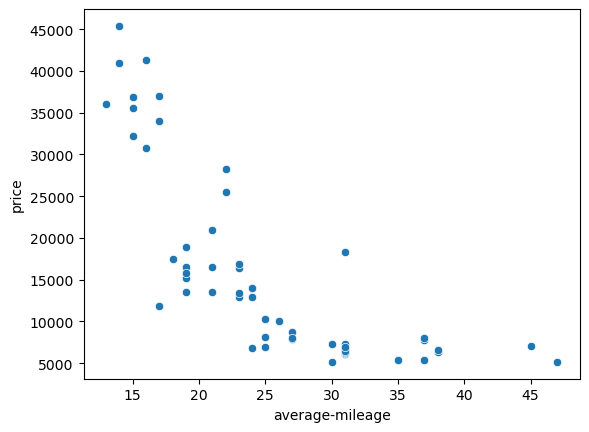

In [102]:
sns.scatterplot(data=df, x='average-mileage', y='price')

<Axes: xlabel='average-mileage', ylabel='price'>

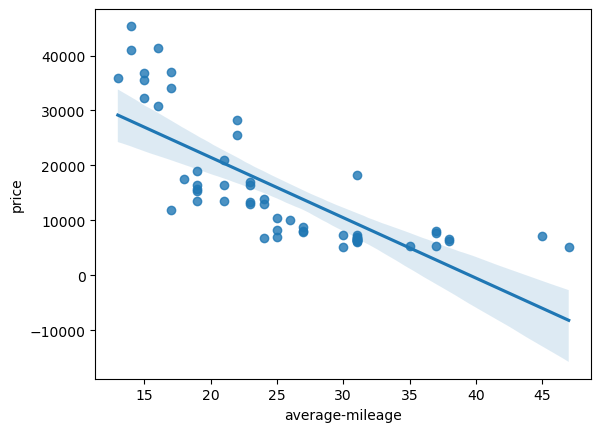

In [103]:
sns.regplot(data=df, x='average-mileage', y='price')